Dataset extracted to: C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\ext dataset
Processing dataset and comparing histograms...
Found 5640 images. Displaying top 3 matches:


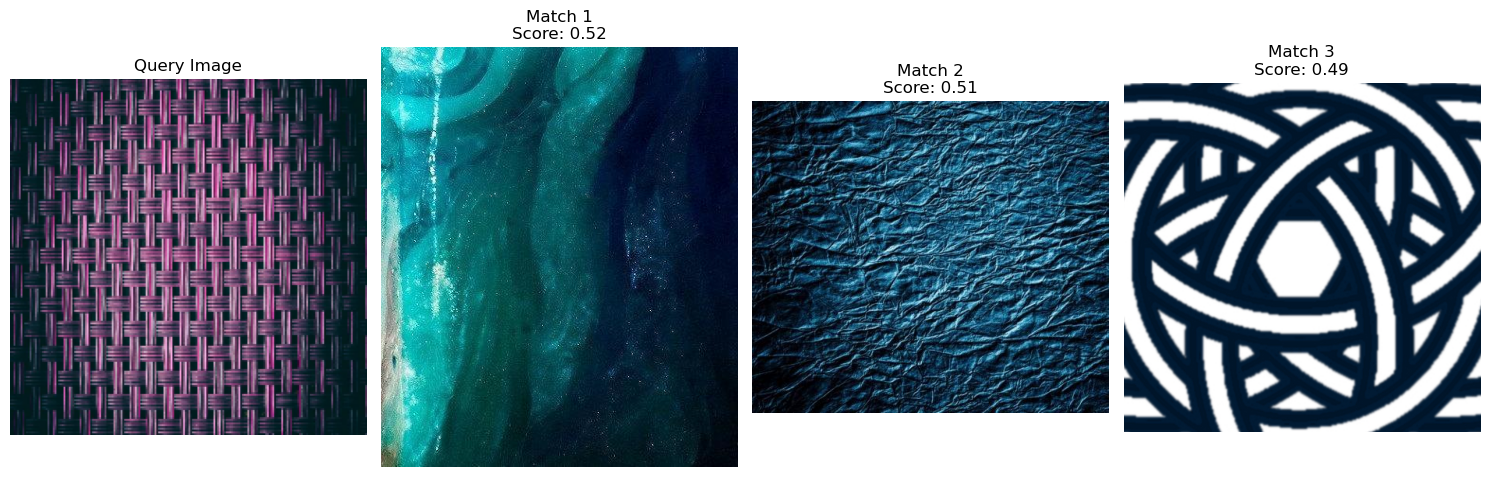

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import shutil

zip_file_path = r"C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\dtd-r1.0.1.tar.gz"  # Path to your local zip
query_image_path = r"C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\fabric-texture-1100x733.jpg" # Path to your query image
extract_to_path = r"C:\Users\LENOVO\Desktop\Uni Shiddds\6th semester\Computer Vision Lab\ext dataset"                  # Temporary folder name
# ------------------------------------------

import tarfile  # Add this import at the top

# Step 1: Extract the local .tar.gz dataset
if not os.path.exists(zip_file_path):
    raise FileNotFoundError(f"Could not find the file at: {zip_file_path}")

# Clean up old directory if it exists
if os.path.exists(extract_to_path):
    shutil.rmtree(extract_to_path)

os.makedirs(extract_to_path, exist_ok=True)

# Use tarfile instead of zipfile
try:
    with tarfile.open(zip_file_path, 'r:gz') as tar_ref:
        tar_ref.extractall(extract_to_path)
        print(f"Dataset extracted to: {extract_to_path}")
except tarfile.TarError:
    print("Error: The file is not a valid .tar.gz file.")

# Step 2: Histogram extraction function
def get_histogram(img):
    # Using HSV color space works better for color-based matching
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # Calculate a 3D histogram for Hue, Saturation, and Value
    # Using [8, 8, 8] bins for efficiency
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

# Step 3: Read query image
query = cv2.imread(query_image_path)
if query is None:
    raise ValueError(f"Could not read query image at: {query_image_path}")

query_resized = cv2.resize(query, (200, 200))
query_hist = get_histogram(query_resized)

# Step 4: Compare with dataset images
scores = []
print("Processing dataset and comparing histograms...")

for root, dirs, files_list in os.walk(extract_to_path):
    for file in files_list:
        # Ignore system files and non-images
        if file.lower().endswith(('.jpg', '.jpeg', '.png')) and not file.startswith('._'):
            image_path = os.path.join(root, file)
            image = cv2.imread(image_path)

            if image is not None:
                image_resized = cv2.resize(image, (200, 200))
                hist = get_histogram(image_resized)
                # Correlation: 1.0 is a perfect match, 0.0 is no match
                score = cv2.compareHist(query_hist, hist, cv2.HISTCMP_CORREL)
                scores.append((score, file, image))

# Step 5: Display Results
scores.sort(key=lambda x: x[0], reverse=True)
top_matches = scores[:3]

if not top_matches:
    print("No matches found. Check your dataset folder.")
else:
    print(f"Found {len(scores)} images. Displaying top {len(top_matches)} matches:")
    plt.figure(figsize=(15, 5))

    # Show query image
    plt.subplot(1, len(top_matches) + 1, 1)
    plt.imshow(cv2.cvtColor(query_resized, cv2.COLOR_BGR2RGB))
    plt.title("Query Image")
    plt.axis('off')

    # Show results
    for i, (score, fname, img) in enumerate(top_matches):
        plt.subplot(1, len(top_matches) + 1, i + 2)
        # Convert BGR (OpenCV default) to RGB (Matplotlib default)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Match {i+1}\nScore: {score:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


Scanning dataset... this may take a moment.
Processed 500 images.

Displaying Results...


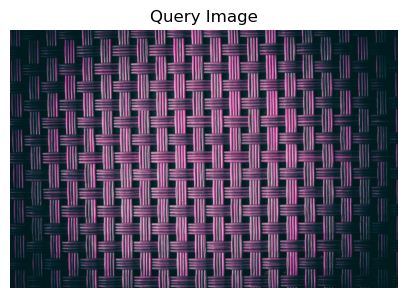

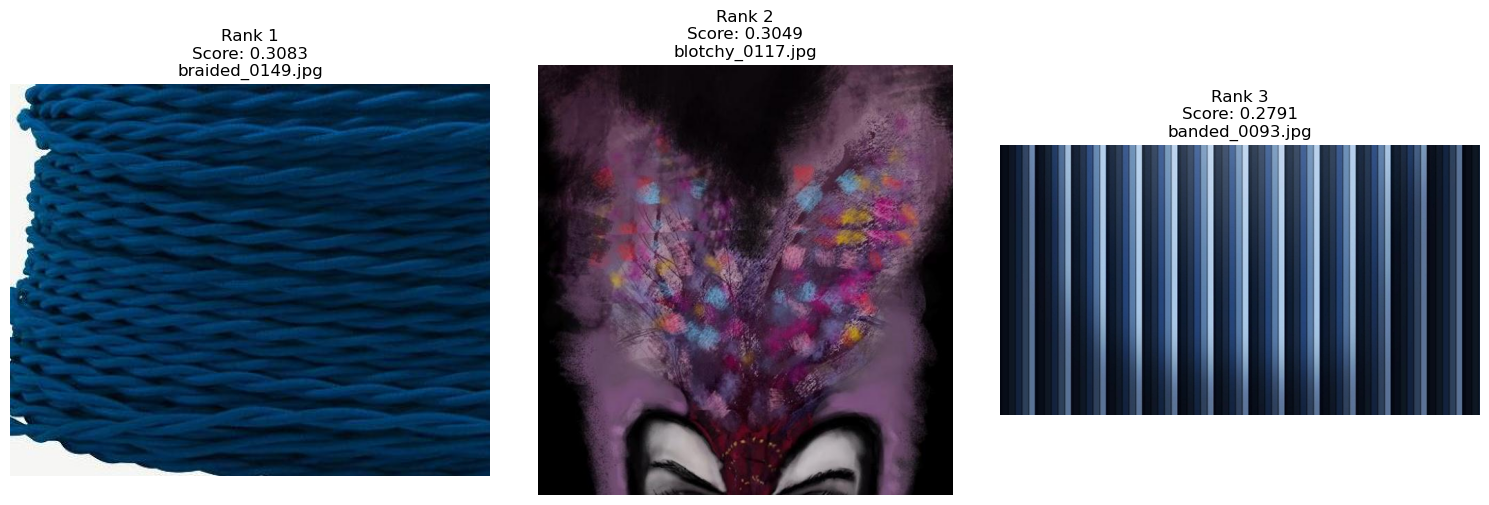

In [7]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 3.20.3 which is incompatible.


Dataset already extracted.
Comparing textures... this may take a moment.


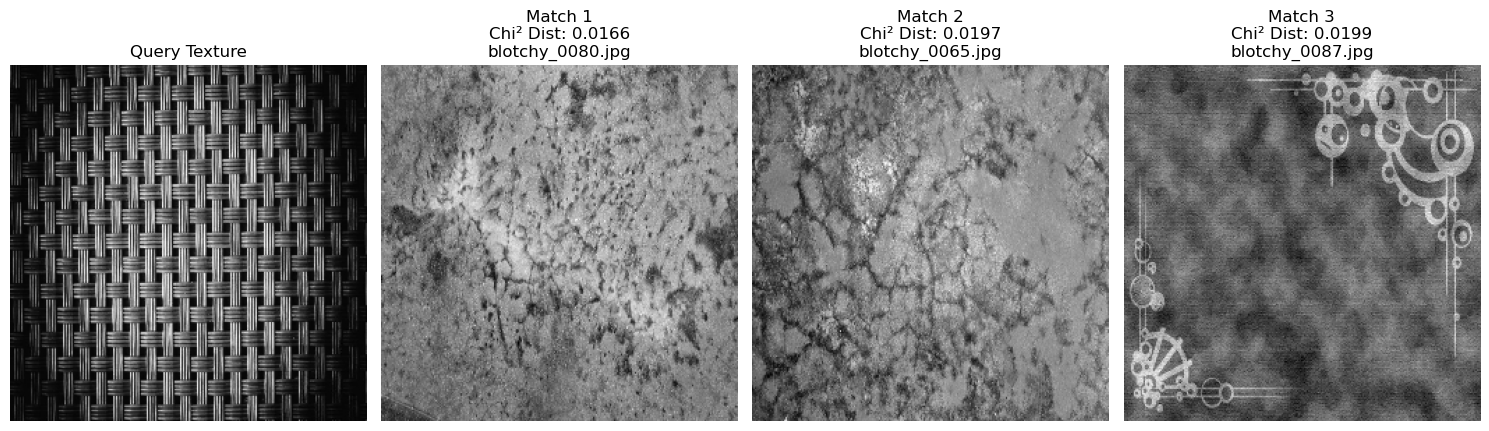